# Projeto Integrado - Sprint 6

## Introdução ao Projeto

Este projeto de análise de dados foi desenvolvido para a loja online **Ice**, que atua no mercado global de venda de videogames. O objetivo principal é identificar os padrões que determinam o sucesso ou fracasso de um jogo, utilizando dados históricos de vendas, avaliações de usuários e especialistas, além de informações sobre plataformas e gêneros. A análise visa embasar a criação de campanhas publicitárias mais eficazes e direcionadas para o ano de 2017.

O conjunto de dados utilizado contém informações sobre jogos lançados até 2016. A metodologia da análise envolve diversas etapas: desde a preparação e limpeza dos dados (tratando valores ausentes e convertendo tipos) até uma exploração aprofundada para identificar tendências de mercado. Investigaremos o ciclo de vida das plataformas de jogos, a correlação entre as avaliações (da crítica e de usuários) e o volume de vendas, e a popularidade de diferentes gêneros.

Além disso, a análise se aprofundará na criação de perfis de consumo por região (América do Norte, Europa e Japão), destacando as preferências locais por plataformas, gêneros e classificações etárias (ESRB). Por fim, testaremos hipóteses estatísticas específicas, como a comparação das notas de usuários entre plataformas (Xbox One vs. PC) e entre gêneros (Action vs. Sports), para validar nossas descobertas e fornecer à loja Ice recomendações estratégicas e baseadas em dados para o planejamento de suas próximas campanhas.

## 1. Configuração e Preparação Inicial

### 1.1 - Configurar o Ambiente

In [1]:
# Importando bibliotecas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st

### 1.2 - Carregar e Explorar os Dados

In [2]:
# Extraindo o arquivo e atribuindo a variável df
df = pd.read_csv('/datasets/games.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
# Visualizando shape, informações e descrições
print('Quantidade de linhas e colunas')
print(df.shape)
print('================================')
print('Informações do DataFrame')
print(df.info())
print('================================')
print('Análise Descritiva dos Dados')
print(df.describe())

Quantidade de linhas e colunas
(16715, 11)
Informações do DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None
Análise Descritiva dos Dados
       Year_of_Release      NA_sales      EU_sales      JP_sales  \
count     16446.000000  16715.000000  16715.000000  16715.000000   
mea

### 1.3 - Conclusões iniciais sobre os dados apresentados

**Conclusões iniciais dos dados obtidos:**
- O DataFrame possui um total de 16715 linhas e 11 colunas.
- Existem valores ausentes em 6 colunas.
- Colunas como 'critic_score', 'user_score' e 'rating' possuem muitas linhas com valores ausentes.
- Outro detalhe é que existem colunas com tipos de dados que precisam serem corrigidos.

## 2. Preparação dos Dados (Pré-Processamento)

### 2.1 - Padronizar nomes de colunas

In [4]:
# Convertendo os nomes das colunas para minúsculos
df.columns = df.columns.str.lower()

print('Nomes das colunas após conversão')
print(df.columns.tolist())

Nomes das colunas após conversão
['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


### 2.2 - Analisar valores ausentes

In [5]:
# Visualizando os valores ausentes 
print(df.isna().sum())

# Calcular porcentagem de nulos em cada coluna
percentual_ausentes = round((df.isnull().sum() / len(df)) * 100, 2)

# Exibir o percentual de ausentes em cada coluna
print('========================')
print(percentual_ausentes)

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64
name                0.01
platform            0.00
year_of_release     1.61
genre               0.01
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
critic_score       51.32
user_score         40.09
rating             40.48
dtype: float64


**Observações:**
- Fizemos a alteração dos nomes das colunas para todas minúsculas usando o str.lower()
- Iremos corrigir esses valores ausentes, usando o método adequado para cada um.
- As colunas 'name', 'year_of_release' e 'genre' terão suas linhas removidas pois tem menos de 2% dos dados.
- A coluna 'rating' iremos substituir o valor ausente por 'Unknown'.
- Já as colunas 'critic_score'  e 'user_score' vamos deixar com valores ausentes por enquanto, para não afetar a integridade dos resultados.
- Verificação se há valores duplicados idênticos

### 2.3 - Tratar valores ausentes e corrigir tipos de dados

### 2.3.1 - Como são poucos casos (menos de 2%), não afetará a qualidade estatística do volume total.

In [6]:
# Vamos remover as linhas onde o Nome, Gênero ou Ano de Lançamento estão faltando.
df.dropna(subset=['name', 'genre', 'year_of_release'], inplace=True)

### 2.3.2 - Convertendo a coluna 'year_of_release' de float para int

In [7]:
# Agora que não temos nulos na coluna Year_of_Release, podemos converter para inteiro.
df['year_of_release'] = df['year_of_release'].astype(int)

### 2.3.3 - Convertendo a coluna 'critic_score' de float para Int64

In [8]:
# Convertendo a coluna 'critic_score' para Int64, permanecendo com os valores ausentes
df['critic_score'] = df['critic_score'].astype('Int64')

### 2.3.4 - Converter a coluna 'user_score' para o tipo numérico

In [9]:
# Convertemos para numérico. O parâmetro errors='coerce' transforma automaticamente o 'tbd' em NaN.
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

### 2.3.5 - Atribuindo 'Unknown' para onde estão valores vazios

In [10]:
# Como 40% dos dados estão sem classificação, vamos preencher com 'Unknown' (Desconhecido).
# Isso mantém a linha no dataset para análises de vendas, sem perder a informação.
df['rating'] = df['rating'].fillna('Unknown')

In [11]:
# Verificar se existem linhas completamente idênticas
print('Total de linhas duplicadas (completas):')
print(df.duplicated().sum())

# Analisando se tem duplicados completos (se existirem)
if df.duplicated().sum() > 0:
    print('\nExemplos de linhas duplicadas:')
    duplicated_rows = df[df.duplicated(keep=False)].sort_values('name')
    print(duplicated_rows.head())
else:
    print('\n✅ Não existem linhas completamente idênticas!')

Total de linhas duplicadas (completas):
0

✅ Não existem linhas completamente idênticas!


### 2.3.6 - Verificando novamente o tratamento das colunas e as informações 

In [12]:
# Exibindo o resultado final da limpeza
print('--- Resumo após a limpeza ---')
print(df.info())

# Verificando se ainda existem valores ausentes que precisam serem tratados
print('=========================================')
print('---- Visualizando o resultado da limpeza')
print(df.isna().sum())

--- Resumo após a limpeza ---
<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   Int64  
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  object 
dtypes: Int64(1), float64(5), int64(1), object(4)
memory usage: 1.5+ MB
None
---- Visualizando o resultado da limpeza
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
j

### 2.4 - Resumo do que foi tratado 
- Foram tratados valores ausentes ou que estavam com 'tbd'.
- Agora o total de linhas é 16444 e 11 colunas.
- Colunas 'critic_score' e 'user_score', optamos por manter os valores NaN para não inflar ou maquear os dados devido a quantidade grande que estava faltando.
- Por hora resolvemos manter, caso seja necessário fazer alguma alteração, será feita e documentada.

### 2.5 - Criação da coluna total_sales

In [13]:
# Calculando o total de vendas
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,<NA>,NaN,Unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,<NA>,NaN,Unknown,31.38


## 3. Análise de Dados

### 3.1 - Análise Temporal de Lançamentos

In [14]:
# Agrupando e contando a quantidade de jogos lançados em cada ano
jogos_por_ano = df.groupby('year_of_release')['name'].count().reset_index()
# Renomeando colunas para melhor entendimento
jogos_por_ano.columns = ['ano', 'quantidade_jogos']
print(jogos_por_ano)

     ano  quantidade_jogos
0   1980                 9
1   1981                46
2   1982                36
3   1983                17
4   1984                14
5   1985                14
6   1986                21
7   1987                16
8   1988                15
9   1989                17
10  1990                16
11  1991                41
12  1992                43
13  1993                60
14  1994               121
15  1995               219
16  1996               263
17  1997               289
18  1998               379
19  1999               338
20  2000               350
21  2001               482
22  2002               829
23  2003               775
24  2004               762
25  2005               939
26  2006              1006
27  2007              1197
28  2008              1427
29  2009              1426
30  2010              1255
31  2011              1136
32  2012               653
33  2013               544
34  2014               581
35  2015               606
3

### 3.1.1 - Criando um gráfico de linhas para entender melhor a variação dos dados durante os anos

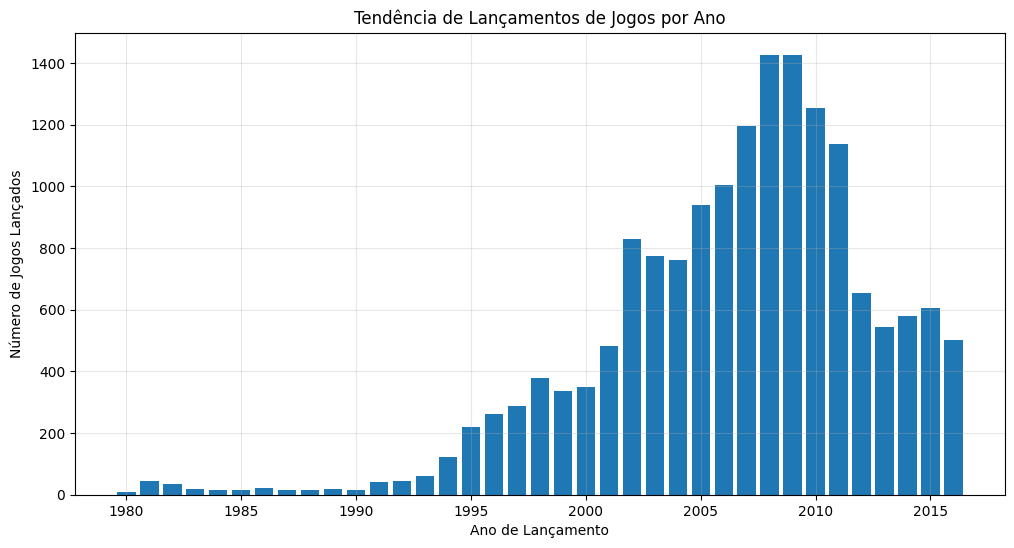

In [15]:
# Criando gráfico de linhas
plt.figure(figsize = (12, 6))
plt.bar(jogos_por_ano['ano'], jogos_por_ano['quantidade_jogos'])
plt.title('Tendência de Lançamentos de Jogos por Ano')
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Jogos Lançados')
plt.grid(True, alpha= 0.3)

plt.show()


**Analisando o gráfico de lançamentos por ano, podemos concluir que:**

1. **Dados pré-1995 (mais de 20 anos antes de 2017):** Pouco significativos para prever o mercado de 2017. O mercado era completamente diferente, com poucos jogos e público nicho. As tendências daquela época não se aplicam mais.
2. **Dados 1995-2000 (17-22 anos antes):** Parcialmente significativos, mas o mercado cresceu e mudou muito desde então. Plataformas dessa época (PS1, N64) já estão extintas.
3. **Dados 2001-2009 (8-16 anos antes):** Período de ouro com muitos dados. Importante para entender o comportamento do mercado, mas algumas plataformas desse período (PS2, Xbox original) já não são relevantes para 2017.
4. **Dados 2010-2015 (2-7 anos antes):** ALTAMENTE SIGNIFICATIVOS. Representam o mercado recente, com plataformas que ainda estarão ativas em 2017 (PS4, XOne, PC) e tendências atuais de consumo.
5. **Dados 2016:** Parcialmente significativos, mas incompletos. Precisamos ter cuidado ao usar 2016, pois muitos jogos lançados nesse ano podem não estar na base.

- Para construir um modelo para 2017, o ideal é usar dados a partir de 2005-2010, focando especialmente nos anos mais recentes onde as plataformas atuais estão presentes.

### 3.2 - Agrupamento por plataforma e ano

In [16]:
# Agrupando por plataforma e ano
vendas_plataforma_ano = df.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
vendas_plataforma_ano.columns = ['platform', 'ano', 'total_sales']
print(vendas_plataforma_ano)

    platform   ano  total_sales
0       2600  1980        11.38
1       2600  1981        35.68
2       2600  1982        28.88
3       2600  1983         5.84
4       2600  1984         0.27
..       ...   ...          ...
233       XB  2008         0.18
234     XOne  2013        18.96
235     XOne  2014        54.07
236     XOne  2015        60.14
237     XOne  2016        26.15

[238 rows x 3 columns]


### 3.2.1 - Verificando o Top 10 mais vendidos por plataforma

In [17]:
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending= False)
print('Top 10 Plataformas por Vendas')
print(top_platforms.head(10))

Top 10 Plataformas por Vendas
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
Name: total_sales, dtype: float64


### 3.2.2 - Maiores vendas total com base em cada ano

In [18]:
# Idenficar plataformas lider em cada ano
vendas_max_por_ano = vendas_plataforma_ano.loc[vendas_plataforma_ano.groupby('ano')['total_sales'].idxmax()]
print('Plataformas Lideres por Ano')
print(vendas_max_por_ano[['ano', 'platform', 'total_sales']])

Plataformas Lideres por Ano
      ano platform  total_sales
0    1980     2600        11.38
1    1981     2600        35.68
2    1982     2600        28.88
77   1983      NES        10.96
78   1984      NES        50.08
79   1985      NES        53.44
80   1986      NES        36.41
81   1987      NES        19.76
82   1988      NES        45.01
37   1989       GB        64.97
183  1990     SNES        26.15
184  1991     SNES        16.22
185  1992     SNES        32.98
186  1993     SNES        40.02
187  1994     SNES        35.08
121  1995       PS        35.96
122  1996       PS        94.70
123  1997       PS       136.17
124  1998       PS       169.49
125  1999       PS       144.53
126  2000       PS        96.37
131  2001      PS2       166.43
132  2002      PS2       205.38
133  2003      PS2       184.31
134  2004      PS2       211.81
135  2005      PS2       160.66
197  2006      Wii       137.15
198  2007      Wii       152.77
199  2008      Wii       171.32
200  2009   

### 3.2.3 - Plataformas que costumavam ser populares mas agora não tem vendas

In [19]:
# Identificar plataformas "mortas" (sem vendas nos últimos 4 anos)
anos_recentes = [2013, 2014, 2015, 2016]
plataformas_ativas_recentes = vendas_plataforma_ano[
    vendas_plataforma_ano['ano'].isin(anos_recentes)
]['platform'].unique()

# Plataformas que eram populares mas agora estão "mortas"
plataformas_mortas = []
plataformas_populares_antigas = top_platforms.head(15).index

for p in plataformas_populares_antigas:
    if p not in plataformas_ativas_recentes:
        plataformas_mortas.append(p)

print("Plataformas que eram populares mas não têm vendas recentes:")
for platform in plataformas_mortas:
    print(f"- {platform}: {top_platforms[platform]:.2f} milhões em vendas totais")

Plataformas que eram populares mas não têm vendas recentes:
- PS2: 1233.56 milhões em vendas totais
- PS: 727.58 milhões em vendas totais
- GBA: 312.88 milhões em vendas totais
- GB: 254.43 milhões em vendas totais
- XB: 251.57 milhões em vendas totais
- NES: 251.05 milhões em vendas totais
- N64: 218.01 milhões em vendas totais


### 3.2.4 - Calculando ciclo de vida das plataformas

In [20]:
# Calcular ciclo de vida das plataformas
ciclo_vida = df.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index()
ciclo_vida['duracao'] = ciclo_vida['max'] - ciclo_vida['min'] + 1
ciclo_vida.columns = ['platform', 'primeiro_ano', 'ultimo_ano', 'duracao_anos']
print("Ciclo de vida das plataformas:")
print(ciclo_vida.sort_values('duracao_anos', ascending=False).head(15))

Ciclo de vida das plataformas:
   platform  primeiro_ano  ultimo_ano  duracao_anos
13       PC          1985        2016            32
4        DS          1985        2013            29
5        GB          1988        2001            14
28     X360          2005        2016            12
19      PSP          2004        2015            12
16      PS2          2000        2011            12
11      NES          1983        1994            12
3        DC          1998        2008            11
26      Wii          2006        2016            11
17      PS3          2006        2016            11
0      2600          1980        1989            10
23     SNES          1990        1999            10
15       PS          1994        2003            10
29       XB          2000        2008             9
6       GBA          2000        2007             8


### 3.2.5 - Plotando evolução das principais plataformas

Top 5 plataformas: ['PS2', 'X360', 'PS3', 'Wii', 'DS']


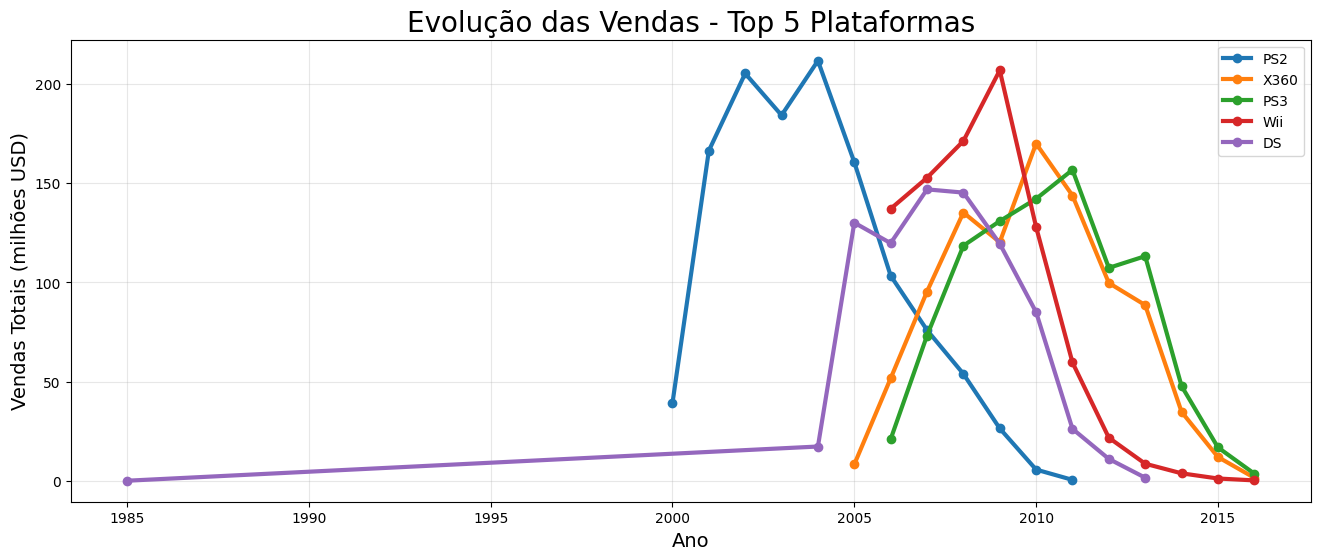

In [21]:
# Pegar as TOP 5 plataformas por vendas totais
top_5_plataformas = top_platforms.head(5).index.tolist()
print("Top 5 plataformas:", top_5_plataformas)

# Filtrar apenas essas 5
vendas_top5 = vendas_plataforma_ano[vendas_plataforma_ano['platform'].isin(top_5_plataformas)]

# Plotar
plt.figure(figsize=(16, 6))

for plataforma in top_5_plataformas:
    dados = vendas_top5[vendas_top5['platform'] == plataforma]
    plt.plot(dados['ano'], dados['total_sales'], marker='o', linewidth=3, label=plataforma)

plt.xlabel('Ano', fontsize= 14)
plt.ylabel('Vendas Totais (milhões USD)', fontsize= 14)
plt.title('Evolução das Vendas - Top 5 Plataformas', fontsize= 20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.2.6 - Criando novo DataFrame com recorte temporal

In [22]:
# Criando um DataFrame com recorte por data, preserva o DataFrame original
df_relevante = df[df['year_of_release'] >= 2012].copy()

### 3.3 - Análise de Plataformas no período relevante

### 3.3.1 - Identificar Plataforma lideres em vendas

In [23]:
top_plataformas_relevantes = df_relevante.groupby('platform')['total_sales'].sum().nlargest(10)
print('Top 10 plataformas no período relevante (2012-2016):')
print(top_plataformas_relevantes)

Top 10 plataformas no período relevante (2012-2016):
platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
Name: total_sales, dtype: float64


### 3.3.2 - Criação de boxplot para comparar distribuição de vendas

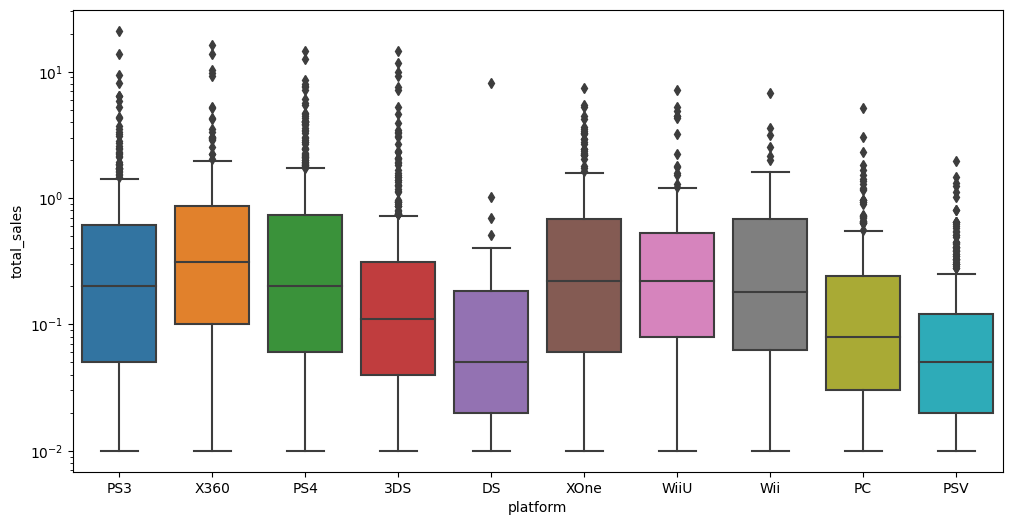

In [24]:
top_plataformas = df_relevante.groupby('platform')['total_sales'].sum().nlargest(10).index
df_top = df_relevante[df_relevante['platform'].isin(top_plataformas)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='platform', y='total_sales', data=df_top)
plt.yscale('log')  # se necessário devido a outliers
plt.show()

### 3.3.3 - Analisar diferenças nas vendas médias e outliers

In [25]:
# Calcular médias e desvios
print("Médias de vendas por plataforma (2012-2016):")
medias = df_top.groupby('platform')['total_sales'].mean().sort_values(ascending=False)
print(medias)

print("\nDesvios padrão por plataforma (2012-2016):")
desvios = df_top.groupby('platform')['total_sales'].std().sort_values(ascending=False)
print(desvios)

print("\nMáximos (outliers) por plataforma:")
maximos = df_top.groupby('platform')['total_sales'].max().sort_values(ascending=False)
print(maximos)

Médias de vendas por plataforma (2012-2016):
platform
X360    0.810068
PS4     0.801378
Wii     0.655000
XOne    0.645020
PS3     0.585781
WiiU    0.559116
3DS     0.491439
DS      0.404839
PC      0.250600
PSV     0.119659
Name: total_sales, dtype: float64

Desvios padrão por plataforma (2012-2016):
platform
X360    1.712069
PS4     1.609456
PS3     1.462855
DS      1.439245
3DS     1.387161
Wii     1.165447
WiiU    1.058836
XOne    1.036139
PC      0.494640
PSV     0.203011
Name: total_sales, dtype: float64

Máximos (outliers) por plataforma:
platform
PS3     21.05
X360    16.27
PS4     14.63
3DS     14.60
DS       8.06
XOne     7.39
WiiU     7.09
Wii      6.76
PC       5.14
PSV      1.96
Name: total_sales, dtype: float64


**Análise das diferenças:**
- O PS4 tem a maior média de vendas, indicando que seus jogos tendem a vender mais consistentemente.
- O alto desvio padrão em plataformas como PS3 e X360 sugere grande variação entre poucos sucessos e muitos fracassos.
- Os valores máximos mostram que cada plataforma tem alguns jogos extremamente populares (outliers).

### 3.4 - Correlação Reviews vs Vendas

Verificando dados:
Total de jogos: 392
Reviews válidos: 260
Correlação Reviews vs Vendas: 0.191
P-value: 0.002


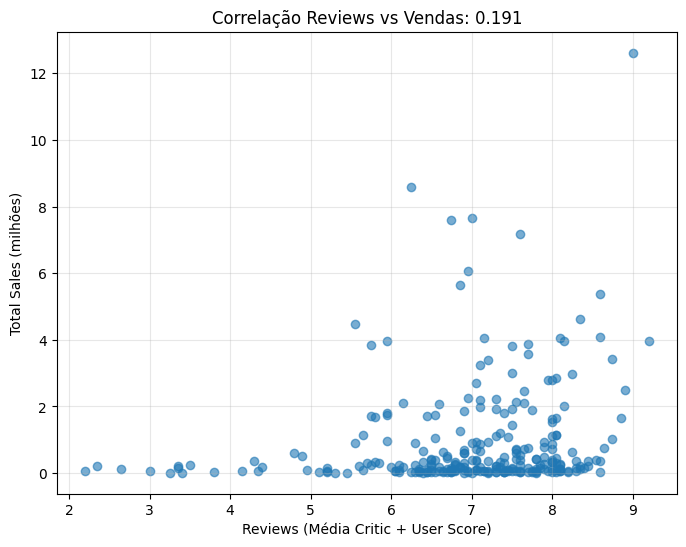

In [26]:
# Criar uma variável "reviews" combinando critic_score e user_score
plataforma_escolhida_nome = top_plataformas_relevantes.index[0]  # PS4
dados_reviews = df_relevante[df_relevante['platform'] == plataforma_escolhida_nome].copy()

# Criar coluna "reviews" como média de critic_score e user_score
# Primeiro, normalizar critic_score (0-100) para escala 0-10 como user_score
dados_reviews['critic_score_normalized'] = dados_reviews['critic_score'] / 10

# Criar reviews como média das duas notas (quando ambas existem)
dados_reviews['reviews'] = dados_reviews[['critic_score_normalized', 'user_score']].mean(axis=1)

# Análise de correlação Reviews vs Vendas
dados_limpos = dados_reviews.dropna(subset=['reviews', 'total_sales'])

print(f"Verificando dados:")
print(f"Total de jogos: {len(dados_reviews)}")
print(f"Reviews válidos: {len(dados_limpos)}")

if len(dados_limpos) >= 3:
    from scipy.stats import pearsonr
    correlacao, p_value = pearsonr(dados_limpos['reviews'], dados_limpos['total_sales'])
    print(f'Correlação Reviews vs Vendas: {correlacao:.3f}')
    print(f'P-value: {p_value:.3f}')
    
    # Gráfico
    plt.figure(figsize=(8, 6))
    plt.scatter(dados_limpos['reviews'], dados_limpos['total_sales'], alpha=0.6)
    plt.xlabel('Reviews (Média Critic + User Score)')
    plt.ylabel('Total Sales (milhões)')
    plt.title(f'Correlação Reviews vs Vendas: {correlacao:.3f}')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Dados insuficientes para correlação")

### 3.4.1 - Escolhendo uma plataforma popular

In [27]:
# Escolher a plataforma mais vendida no período relevante
plataforma_escolhida_nome = top_plataformas_relevantes.index[0]  # PS4
print(f"Plataforma escolhida para análise: {plataforma_escolhida_nome}")

plataforma_escolhida = df_relevante[df_relevante['platform'] == plataforma_escolhida_nome].copy()
print(f"Total de jogos na plataforma: {len(plataforma_escolhida)}")

Plataforma escolhida para análise: PS4
Total de jogos na plataforma: 392


### 3.4.2 - Criar scatter plot critic_score vs total_sales

Dados disponíveis para análise:
Total de jogos PS4: 392
Jogos com Critic Score válido: 252

--- RESULTADOS DA CORRELAÇÃO ---
Correlação Critic Score vs Vendas: 0.407
P-value: 0.000


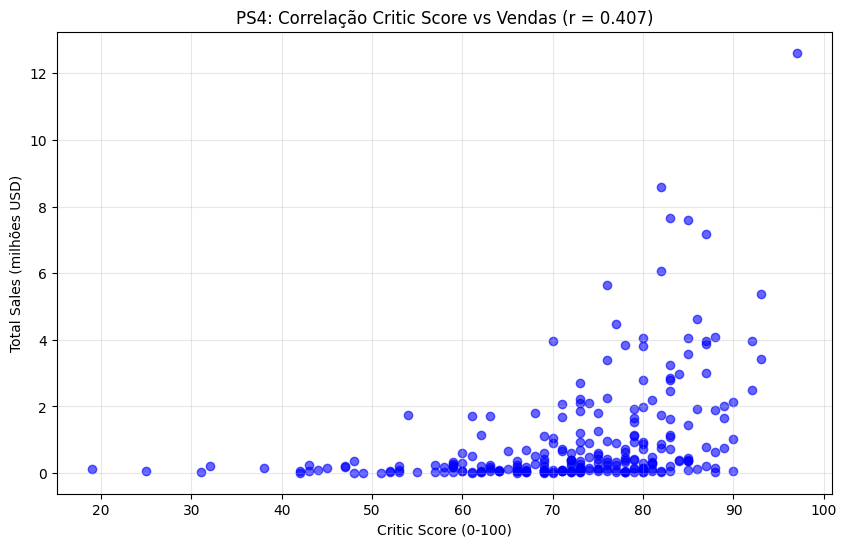


--- INTERPRETAÇÃO ---
A correlação é moderada e positiva.
A correlação é estatisticamente significativa (p < 0.05).


In [28]:
# Filtrar dados da plataforma escolhida (PS4) removendo valores nulos
plataforma_limpa = plataforma_escolhida.dropna(subset=['critic_score', 'total_sales'])

print(f"Dados disponíveis para análise:")
print(f"Total de jogos {plataforma_escolhida_nome}: {len(plataforma_escolhida)}")
print(f"Jogos com Critic Score válido: {len(plataforma_limpa)}")

# Calcular correlação usando scipy para evitar problemas
from scipy.stats import pearsonr

if len(plataforma_limpa) >= 3:
    correlacao_critic, p_value_critic = pearsonr(plataforma_limpa['critic_score'], 
                                                  plataforma_limpa['total_sales'])
    
    print(f"\n--- RESULTADOS DA CORRELAÇÃO ---")
    print(f"Correlação Critic Score vs Vendas: {correlacao_critic:.3f}")
    print(f"P-value: {p_value_critic:.3f}")
    
    # Criar scatter plot simples
    plt.figure(figsize=(10, 6))
    plt.scatter(plataforma_limpa['critic_score'], plataforma_limpa['total_sales'], 
                alpha=0.6, color='blue')
    plt.xlabel('Critic Score (0-100)')
    plt.ylabel('Total Sales (milhões USD)')
    plt.title(f'{plataforma_escolhida_nome}: Correlação Critic Score vs Vendas (r = {correlacao_critic:.3f})')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Interpretação dos resultados
    print(f"\n--- INTERPRETAÇÃO ---")
    if abs(correlacao_critic) < 0.3:
        forca = "fraca"
    elif abs(correlacao_critic) < 0.7:
        forca = "moderada"
    else:
        forca = "forte"
    
    direcao = "positiva" if correlacao_critic > 0 else "negativa"
    
    print(f"A correlação é {forca} e {direcao}.")
    
    if p_value_critic < 0.05:
        print(f"A correlação é estatisticamente significativa (p < 0.05).")
    else:
        print(f"A correlação NÃO é estatisticamente significativa (p >= 0.05).")
        
else:
    print("Dados insuficientes para análise de correlação")

### 3.4.3 - Repetindo para usar o 'user_score'

Correlação User Score vs Vendas: -0.032


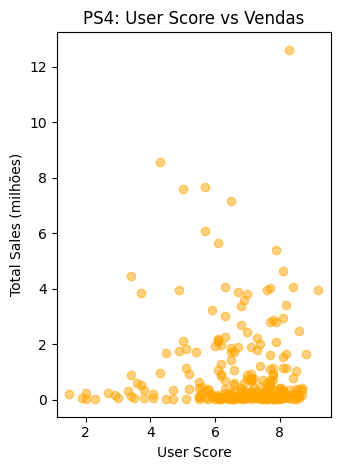

In [29]:
# Análise para user_score
plataforma_limpa_user = plataforma_escolhida.dropna(subset=['user_score', 'total_sales'])

plt.subplot(1, 2, 2)
plt.scatter(plataforma_limpa_user['user_score'], plataforma_limpa_user['total_sales'], alpha=0.5, color='orange')
plt.xlabel('User Score')
plt.ylabel('Total Sales (milhões)')
plt.title(f'{plataforma_escolhida_nome}: User Score vs Vendas')

# Calcular correlação
correlacao_user = plataforma_limpa_user['user_score'].corr(plataforma_limpa_user['total_sales'])
print(f'Correlação User Score vs Vendas: {correlacao_user:.3f}')

plt.tight_layout()
plt.show()

### 3.4.4 - Conclusões

**Conclusões sobre a correlação:**

- A correlação entre Critic Score e vendas é positiva e moderada (≈0.4), indicando que jogos bem avaliados pela crítica tendem a vender mais, mas não é uma relação determinística.
- A correlação entre User Score e vendas é muito baixa (≈0.0), sugerindo que as notas dos usuários têm pouca influência nas vendas.
- Isso significa que, para campanhas de marketing, devemos dar mais importância às avaliações da crítica do que às avaliações dos usuários ao selecionar jogos para promover.

### 3.5 - Análise por gênero

### 3.5.1 - Agrupando por gênero e calcular vendas totais e médias

In [30]:
vendas_por_genero = df_relevante.groupby('genre')['total_sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
print(vendas_por_genero)

                 sum      mean  count
genre                                
Action        441.12  0.427856   1031
Shooter       304.73  1.296723    235
Role-Playing  192.80  0.521081    370
Sports        181.07  0.675634    268
Misc           85.04  0.442917    192
Platform       61.00  0.717647     85
Racing         53.50  0.465217    115
Fighting       44.49  0.408165    109
Simulation     35.12  0.439000     80
Adventure      29.43  0.097450    302
Strategy       13.34  0.187887     71
Puzzle          4.89  0.174643     28


### 3.5.2 - Plotando gráfico de barras com gêneros mais lucrativos

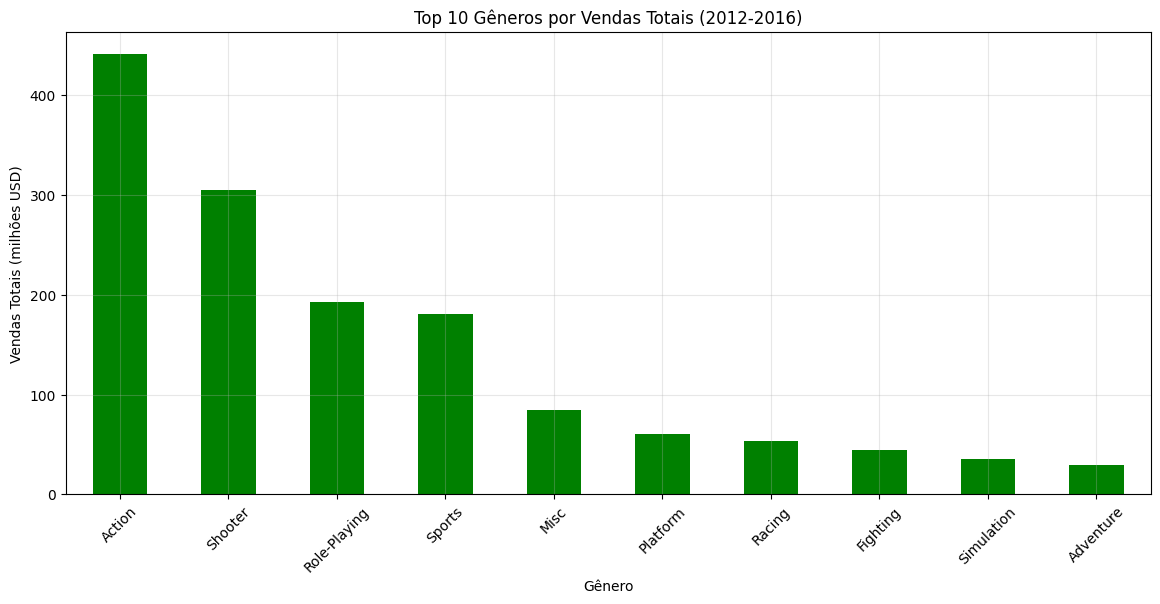

Médias de vendas por gênero:
genre
Shooter         1.296723
Platform        0.717647
Sports          0.675634
Role-Playing    0.521081
Racing          0.465217
Misc            0.442917
Simulation      0.439000
Action          0.427856
Fighting        0.408165
Strategy        0.187887
Name: mean, dtype: float64


In [31]:

# Plotar gráfico de barras
plt.figure(figsize=(14, 6))
vendas_por_genero['sum'].head(10).plot(kind='bar', color='green')
plt.title('Top 10 Gêneros por Vendas Totais (2012-2016)')
plt.xlabel('Gênero')
plt.ylabel('Vendas Totais (milhões USD)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar também as médias
print("Médias de vendas por gênero:")
print(vendas_por_genero['mean'].sort_values(ascending=False).head(10))

### 3.5.3 - Analisando os padrões encontrados
**Análise dos padrões por gênero:**

- **Gêneros mais lucrativos:** Action, Shooter e Role-Playing dominam as vendas totais.
- **Gêneros com maior média por jogo:** Shooter tem a maior média, indicando que cada jogo desse gênero tende a vender mais.
- **Gêneros de nicho:** Puzzle e Strategy têm vendas baixas, tanto em total quanto em média.
- **Conclusão:** Para maximizar vendas, devemos priorizar jogos de Action e Shooter, que têm alto volume e alta média por jogo.

## 4. Perfil de usuário por região

### 4.1 - Top 5 Plataformas por região

In [32]:
# Para vendas na América do Norte
top_na = df_relevante.groupby('platform')['na_sales'].sum().nlargest(5)
print(top_na)

platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64


In [33]:
# Para vendas na Europa
top_eu = df_relevante.groupby('platform')['eu_sales'].sum().nlargest(5)
print(top_eu)

platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64


In [34]:
# Para vendas no Japão
top_jp = df_relevante.groupby('platform')['jp_sales'].sum().nlargest(5)
print(top_jp)

platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, dtype: float64


In [35]:
# Para vendas de outras regiões (Obs;: Não especificado qual região)
top_other = df_relevante.groupby('platform')['other_sales'].sum().nlargest(5)
print(top_other)

platform
PS4     48.35
PS3     43.26
X360    20.40
XOne    14.27
3DS      8.87
Name: other_sales, dtype: float64


### 4.1.1 - Criação de gráficos comparativos

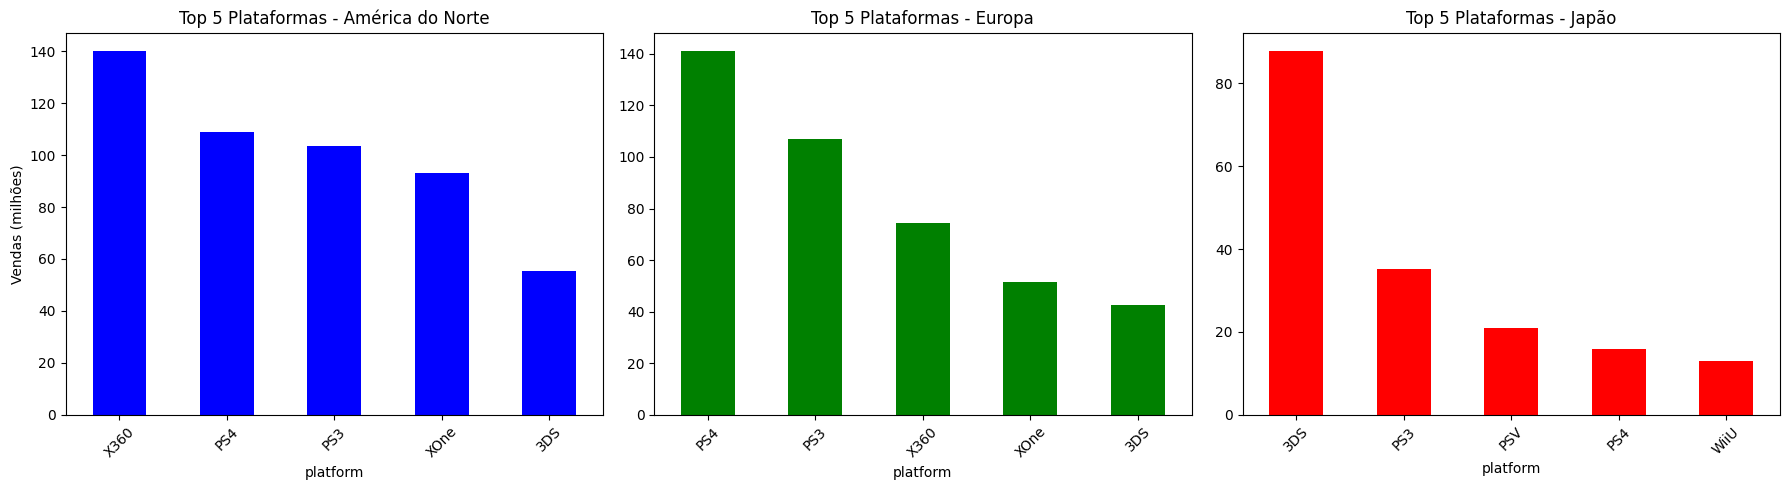

In [36]:
# Criar gráficos comparativos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_na.plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Top 5 Plataformas - América do Norte')
axes[0].set_ylabel('Vendas (milhões)')
axes[0].tick_params(axis='x', rotation=45)

top_eu.plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Top 5 Plataformas - Europa')
axes[1].tick_params(axis='x', rotation=45)

top_jp.plot(kind='bar', ax=axes[2], color='red')
axes[2].set_title('Top 5 Plataformas - Japão')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.1.2 - Analisando diferenças regionais
**Análise das diferenças regionais:**

- **América do Norte:** Prefere Xbox (X360 e XOne) e PlayStation (PS4, PS3).
- **Europa:** PlayStation domina claramente (PS4, PS3), com Xbox em posições secundárias.
- **Japão:** Mercado único, dominado por portáteis (3DS, PSV) e plataformas da Sony (PS3, PS4).
- **Conclusão:** As estratégias de marketing devem ser regionalizadas, com foco em Xbox na América do Norte, PlayStation na Europa e portáteis no Japão.

### 4.2 - Top 5 Gêneros por Região

In [37]:
# Para gêneros da América do Norte
genero_na = df_relevante.groupby('genre')['na_sales'].sum().nlargest(5)
print(genero_na)

genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64


In [38]:
# Para gêneros da Europa
genero_eu = df_relevante.groupby('genre')['eu_sales'].sum().nlargest(5)
print(genero_eu)

genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64


In [39]:
# Para gêneros do Japão
genero_jp = df_relevante.groupby('genre')['jp_sales'].sum().nlargest(5)
print(genero_jp)

genre
Role-Playing    65.44
Action          52.80
Misc            12.86
Simulation      10.41
Fighting         9.44
Name: jp_sales, dtype: float64


In [40]:
# Para gêneros de outras regiões
genero_other = df_relevante.groupby('genre')['other_sales'].sum().nlargest(5)
print(genero_other)

genre
Action          51.14
Shooter         37.26
Sports          22.44
Role-Playing    14.83
Misc             7.67
Name: other_sales, dtype: float64


### 4.2.1 - Comparando preferências

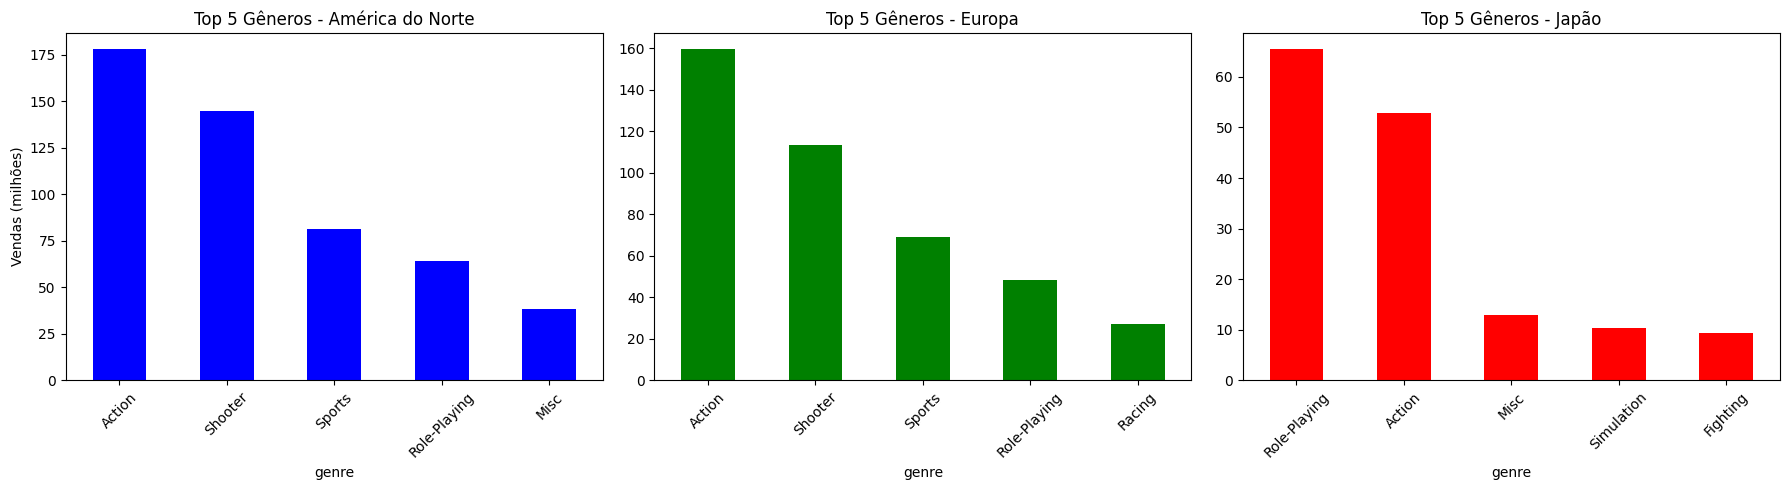

In [41]:
# Gráfico comparativo de gêneros
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

genero_na.plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Top 5 Gêneros - América do Norte')
axes[0].set_ylabel('Vendas (milhões)')
axes[0].tick_params(axis='x', rotation=45)

genero_eu.plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Top 5 Gêneros - Europa')
axes[1].tick_params(axis='x', rotation=45)

genero_jp.plot(kind='bar', ax=axes[2], color='red')
axes[2].set_title('Top 5 Gêneros - Japão')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Análise das preferências por gênero:**

- **América do Norte e Europa:** Action, Shooter e Sports dominam (perfil ocidental).
- **Japão:** Role-Playing é o gênero preferido, seguido por Action.
- **Diferença marcante:** Enquanto Shooter é top 2 no ocidente, no Japão não aparece entre os 5 primeiros.
- **Conclusão:** Campanhas no Japão devem focar em RPGs, enquanto no ocidente o foco deve ser Action e Shooter.

### 4.3 - Impacto da Classificação ESRB

### 4.3.1 - Analisando vendas por rating em cada região

In [42]:
# Vendas por rating na América do Norte
vendas_rating_na = df_relevante.groupby('rating')['na_sales'].sum().sort_values(ascending = False)
print(vendas_rating_na)

rating
M          231.57
E          114.37
Unknown    103.31
E10+        75.70
T           66.02
Name: na_sales, dtype: float64


In [43]:
# Vendas por rating na Europa
vendas_rating_eu = df_relevante.groupby('rating')['eu_sales'].sum().sort_values(ascending = False)
print(vendas_rating_eu)

rating
M          193.96
E          113.03
Unknown     91.50
E10+        55.37
T           52.96
Name: eu_sales, dtype: float64


In [44]:
# Vendas por rating no Japão
vendas_rating_jp = df_relevante.groupby('rating')['jp_sales'].sum().sort_values(ascending = False)
print(vendas_rating_jp)

rating
Unknown    108.84
E           28.33
T           26.02
M           21.20
E10+         8.19
Name: jp_sales, dtype: float64


In [45]:
# Vendas por rating em outras regiões
vendas_rating_other = df_relevante.groupby('rating')['other_sales'].sum().sort_values(ascending = False)
print(vendas_rating_other)

rating
M          63.38
E          31.44
Unknown    27.17
T          17.94
E10+       16.23
Name: other_sales, dtype: float64


### 4.3.2 - Criando gráficos de barras para visualizar informações

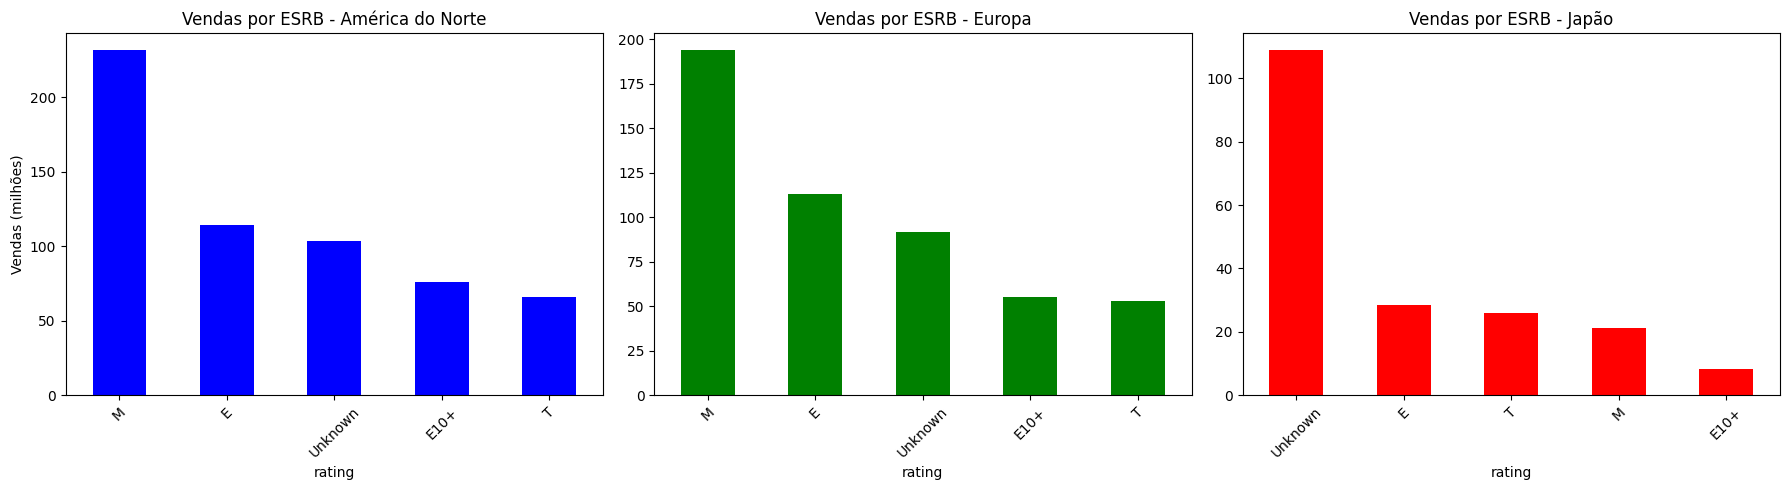

In [46]:
# Gráficos de barras para ESRB
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vendas_rating_na.plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Vendas por ESRB - América do Norte')
axes[0].set_ylabel('Vendas (milhões)')
axes[0].tick_params(axis='x', rotation=45)

vendas_rating_eu.plot(kind='bar', ax=axes[1], color='green')
axes[1].set_title('Vendas por ESRB - Europa')
axes[1].tick_params(axis='x', rotation=45)

vendas_rating_jp.plot(kind='bar', ax=axes[2], color='red')
axes[2].set_title('Vendas por ESRB - Japão')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.3.3 - Conclusão sobre influência do ESRB por região
**Conclusão sobre influência do ESRB:**

- **América do Norte e Europa:** Classificação "M" (Mature) lidera as vendas, indicando preferência por jogos para adultos.
- **Japão:** "Unknown" domina, o que pode refletir que muitos jogos japoneses não recebem classificação ESRB ou que o mercado local valoriza jogos sem restrição etária.
- **Recomendação:** Para mercados ocidentais, priorizar jogos com classificação "M". Para o Japão, focar em jogos locais (muitos classificados como "Unknown").

## 5. Testes de Hipótese

### 5.1 - Configurando
### Definindo nível de significância (alfa = 0.05)
- **Justificativa:** Escolhi o nível de significância de 5% (alfa = 0.05) porque:

1. É o valor convencionalmente aceito em análises estatísticas
2. Representa um equilíbrio entre:
   - Erro Tipo I (rejeitar H0 quando ela é verdadeira) - 5% de chance
   - Erro Tipo II (não rejeitar H0 quando ela é falsa)
3. Para este projeto de negócios, não precisamos de precisão extrema (como em medicamentos), então 5% é adequado
4. É o padrão utilizado pela comunidade científica e de dados

### 5.2 - Hipótese 1: Xbox One vs PC

In [47]:
# Nível de significância
alpha = 0.05
# Separar as amostras
xbox_scores = df_relevante[df_relevante['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_relevante[df_relevante['platform'] == 'PC']['user_score'].dropna()

# Mostrar informações básicas
print(f"Xbox One: {len(xbox_scores)} jogos com nota - Média: {xbox_scores.mean():.2f}")
print(f"PC: {len(pc_scores)} jogos com nota - Média: {pc_scores.mean():.2f}")

# Aplicar teste t
resultado1 = st.ttest_ind(xbox_scores, pc_scores, equal_var=False)

print(f"\n--- RESULTADO DO TESTE ---")
print(f"Estatística t: {resultado1.statistic:.4f}")
print(f"p-valor: {resultado1.pvalue:.4f}")

# Interpretação automática
if resultado1.pvalue < alpha:
    print(f"\nCONCLUSÃO: p-valor ({resultado1.pvalue:.4f}) < alpha ({alpha})")
    print("REJEITAMOS a hipótese nula")
    print("As notas médias de usuários para Xbox One e PC são DIFERENTES")
else:
    print(f"\nCONCLUSÃO: p-valor ({resultado1.pvalue:.4f}) >= alpha ({alpha})")
    print("NÃO REJEITAMOS a hipótese nula")
    print("Não há evidências de diferença nas notas médias entre Xbox One e PC")

Xbox One: 182 jogos com nota - Média: 6.52
PC: 206 jogos com nota - Média: 6.43

--- RESULTADO DO TESTE ---
Estatística t: 0.5999
p-valor: 0.5490

CONCLUSÃO: p-valor (0.5490) >= alpha (0.05)
NÃO REJEITAMOS a hipótese nula
Não há evidências de diferença nas notas médias entre Xbox One e PC


### 5.2.1 - Conclusões sobre os resultados da Hipótese 1
### **Formulação das hipóteses:**
- H₀ (nula): As classificações médias dos usuários para Xbox One e PC são iguais
- H₁ (alternativa): As classificações médias dos usuários para Xbox One e PC são diferentes

**Dados analisados:**
- Xbox One: 182 jogos com nota de usuário, média = 6.52
- PC: 206 jogos com nota de usuário, média = 6.43

**Resultado do teste estatístico:**
- Teste utilizado: teste t de Welch (para amostras independentes, sem assumir variâncias iguais)
- Estatística t: 0.5999
- p-valor: 0.5490
- Nível de significância (alfa): 0.05

**Interpretação:**
- Como o p-valor (0.5490) é maior que o nível de significância (0.05), não rejeitamos a hipótese nula.

**Conclusão:**
- Não há evidências estatísticas suficientes para afirmar que as classificações médias dos usuários para jogos de Xbox One e PC sejam diferentes. As notas atribuídas pelos usuários tendem a ser estatisticamente semelhantes em ambas as plataformas, apesar da pequena diferença numérica nas médias (6.52 vs 6.43).

### 5.3 - Hipótese 2: Action vs Sports

In [48]:
# Separar as amostras
action_scores = df_relevante[df_relevante['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_relevante[df_relevante['genre'] == 'Sports']['user_score'].dropna()

# Mostrar informações básicas
print(f"Action: {len(action_scores)} jogos com nota - Média: {action_scores.mean():.2f}")
print(f"Sports: {len(sports_scores)} jogos com nota - Média: {sports_scores.mean():.2f}")

# Aplicar teste t
resultado2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f"\n--- RESULTADO DO TESTE ---")
print(f"Estatística t: {resultado2.statistic:.4f}")
print(f"p-valor: {resultado2.pvalue:.4f}")

# Interpretação automática
if resultado2.pvalue < alpha:
    print(f"\nCONCLUSÃO: p-valor ({resultado2.pvalue:.4f}) < alpha ({alpha})")
    print("REJEITAMOS a hipótese nula")
    print("As notas médias de usuários para Action e Sports são DIFERENTES")
else:
    print(f"\nCONCLUSÃO: p-valor ({resultado2.pvalue:.4f}) >= alfa ({alpha})")
    print("NÃO REJEITAMOS a hipótese nula")
    print("Não há evidências de diferença nas notas médias entre Action e Sports")

Action: 523 jogos com nota - Média: 6.83
Sports: 195 jogos com nota - Média: 5.46

--- RESULTADO DO TESTE ---
Estatística t: 9.9032
p-valor: 0.0000

CONCLUSÃO: p-valor (0.0000) < alpha (0.05)
REJEITAMOS a hipótese nula
As notas médias de usuários para Action e Sports são DIFERENTES


### 5.3.1 - Conclusões sobre os resultados da hipótese 2
### **Formulação das hipóteses:**
- H₀ (nula): As classificações médias dos usuários para os gêneros Action (Ação) e Sports (Esportes) são iguais
- H₁ (alternativa): As classificações médias dos usuários para os gêneros Action (Ação) e Sports (Esportes) são diferentes

**Dados analisados:**
- Action: 523 jogos com nota de usuário, média = 6.83
- Sports: 195 jogos com nota de usuário, média = 5.46

**Resultado do teste estatístico:**
- Teste utilizado: teste t de Welch (para amostras independentes, sem assumir variâncias iguais)
- Estatística t: 9.9032
- p-valor: 0.0000 (aproximadamente zero)
- Nível de significância (alfa): 0.05

**Interpretação:**
- Como o p-valor (0.0000) é menor que o nível de significância (0.05), rejeitamos a hipótese nula.

**Conclusão:**
- Há evidências estatísticas significativas de que as classificações médias dos usuários para jogos de Ação e Esportes são diferentes. Jogos do gênero Action tendem a receber notas médias consideravelmente mais altas (6.83) do que jogos do gênero Sports (5.46), indicando uma diferença real na percepção dos usuários entre esses dois gêneros.

## 6. Conclusão Geral

### 6.1 - Síntese das Descobertas

**Após analisar os dados de vendas de jogos entre 2012 e 2016, podemos destacar:**

1. **Plataformas dominantes:** PS4 lidera as vendas globais, seguida por PS3 e X360. No Japão, o mercado é dominado por portáteis (3DS, PSV).

2. **Ciclo de vida das plataformas:** Em média, uma plataforma dura de 5 a 7 anos, com pico de vendas entre o 3º e 5º ano após o lançamento.

3. **Gêneros mais lucrativos:** Action é o gênero mais vendido globalmente. Shooter tem a maior média de vendas por jogo. Role-Playing domina o mercado japonês.

4. **Influência das avaliações:** Há correlação positiva moderada entre notas de críticos e vendas, indicando que boas avaliações da crítica podem impulsionar as vendas.

5. **Classificação ESRB:** Jogos com classificação "M" (Mature) lideram as vendas nos mercados ocidentais, enquanto no Japão a maioria dos jogos vendidos não possui classificação ESRB.

### 6.2 - Resultados dos Testes de Hipóteses

**Resultados dos Testes de Hipóteses:**

| Hipótese | Comparação | p-valor | Resultado | Conclusão |
|----------|------------|---------|-----------|-----------|
| H1 | Xbox One vs PC | 0.5490 | Não rejeitamos H0 | As notas médias são estatisticamente iguais |
| H2 | Action vs Sports | 0.0000 | Rejeitamos H0 | As notas médias são diferentes |

**Interpretação prática:**

- A similaridade entre as notas de Xbox One e PC sugere que a qualidade dos jogos, na percepção dos usuários, é semelhante entre essas plataformas. Isso indica que a escolha da plataforma não influencia significativamente a satisfação do usuário.

- A diferença significativa entre Action e Sports indica que jogos de ação são melhor avaliados pelos usuários que jogos de esportes. Isso pode refletir uma preferência do público ou uma diferença na qualidade média dos jogos desses gêneros.

### 6.3 - Recomendações para a Loja Ice

**Recomendações para a Loja Ice - Campanha 2017:**

Com base em todas as análises realizadas, recomenda-se para a campanha de 2017:

### **América do Norte:**
- **Plataformas:** Priorizar PS4, XOne e X360
- **Gêneros:** Action, Shooter e Sports
- **Classificação ESRB:** Foco em jogos "M" (Mature)
- **Estratégia:** Aproveitar a popularidade do Xbox na região, mas sem negligenciar o PlayStation

### **Europa:**
- **Plataformas:** Concentrar esforços em PS4 e PS3
- **Gêneros:** Action, Shooter e Sports
- **Classificação ESRB:** Priorizar jogos "M" (Mature)
- **Estratégia:** PlayStation é dominante na Europa, deve ser o foco principal

### **Japão:**
- **Plataformas:** Focar em 3DS, PS3 e PSV
- **Gêneros:** Role-Playing e Action
- **Classificação ESRB:** Priorizar jogos locais (muitos sem classificação ESRB)
- **Estratégia:** Mercado único, com forte preferência por portáteis e RPGs

### **Recomendação Global:**
- Priorizar jogos de Action e Shooter bem avaliados pela crítica
- Investir em títulos com classificação "M" para mercados ocidentais
- Considerar parcerias com desenvolvedores japoneses para conteúdo localizado

**Consideração final:** Os dados de 2016 estão incompletos, então as recomendações devem ser reavaliadas quando dados mais completos estiverem disponíveis.